# Introduction

# Albotherm AXF — Exploratory Data Analysis
### Pipeline Step 4 of 5: Clean → Merge → EDA → **Testing** → Model

## 1. Import Necessary Library

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.formula.api as smf


## 2. Loading merged dataset

In [2]:
df = pd.read_csv('../../datasets/processed/axf_merged.csv')

## 3. Hypothesis Testing

### 3a. Linear Regression Relationship

In [3]:
model_1 = smf.ols(
    formula="""
    Q('% dry after 24h in humidity') ~
    Q('Impellor Speed (rpm)') +
    Q('Dispersed Flow Rate (mL/min)') +
    Q('Flow Rate Ratio')
    """,
    data=df
).fit()

print(model_1.summary())

                                   OLS Regression Results                                   
Dep. Variable:     Q('% dry after 24h in humidity')   R-squared:                       0.035
Model:                                          OLS   Adj. R-squared:                  0.030
Method:                               Least Squares   F-statistic:                     7.470
Date:                              Thu, 30 Apr 2026   Prob (F-statistic):           6.43e-05
Time:                                      09:43:45   Log-Likelihood:                -2983.2
No. Observations:                               619   AIC:                             5974.
Df Residuals:                                   615   BIC:                             5992.
Df Model:                                         3                                         
Covariance Type:                          nonrobust                                         
                                        coef    std err          t    

This model shows that: 
- Flow Rate Ratio has a statistically significant relationship with % dry 
> Its p-value under 0.05, relationship really have meaning
> Coefficient of it with result is really high than other features (1.3721) - Increase FRR 1 unit will make result increase 1.3721 units
- However, the model has very low explanatory power when R-squared it only 0.035. <br>
<br>
*Therefore, it is useful for initial relationship screening, but not strong enough for prediction.*


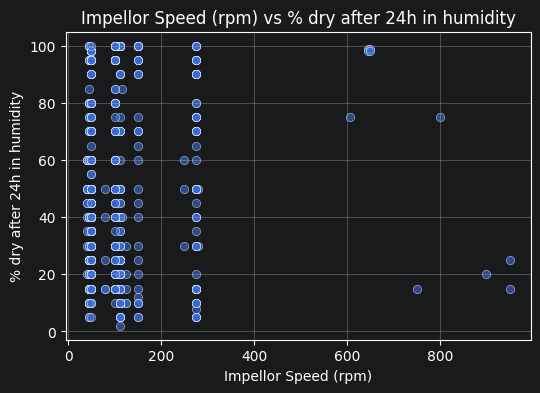

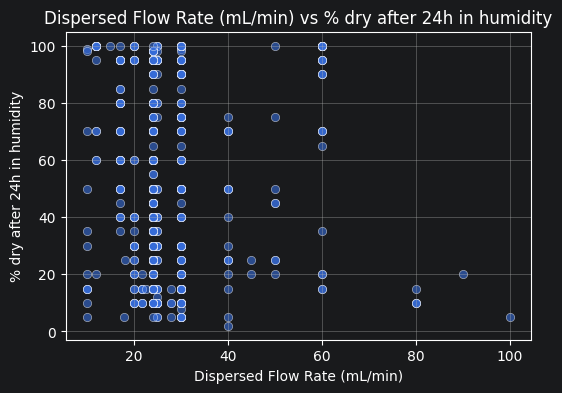

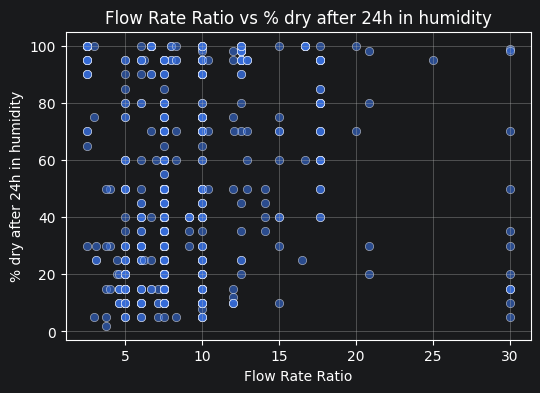

In [9]:
factors = [
    "Impellor Speed (rpm)",
    "Dispersed Flow Rate (mL/min)",
    "Flow Rate Ratio"
]

target = "% dry after 24h in humidity"

for factor in factors:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=factor, y=target, alpha=0.6)
    plt.title(f"{factor} vs {target}")
    plt.grid(True)
    plt.show()

The distribution of feature values ​​is not fixed. Comparing this with the results, we can see that areas with good results (below 20%) are heavily concentrated in a specific region of features, but there are still some exceptions within that concentrated region.

This suggests that their relationships may influence each other (interaction relationships)

### 3b. Interaction Relationship

In [14]:
model_interactions = smf.ols(
    "Q('% dry after 24h in humidity') ~ Q('Flow Rate Ratio') * Q('Dispersed Flow Rate (mL/min)') * Q('Impellor Speed (rpm)')",
    data=df
).fit()

print(model_all_interactions.summary())

                                   OLS Regression Results                                   
Dep. Variable:     Q('% dry after 24h in humidity')   R-squared:                       0.173
Model:                                          OLS   Adj. R-squared:                  0.164
Method:                               Least Squares   F-statistic:                     18.29
Date:                              Thu, 30 Apr 2026   Prob (F-statistic):           3.72e-22
Time:                                      10:32:02   Log-Likelihood:                -2935.4
No. Observations:                               619   AIC:                             5887.
Df Residuals:                                   611   BIC:                             5922.
Df Model:                                         7                                         
Covariance Type:                          nonrobust                                         
                                                                      

Adding interaction terms improved the model from R² = 0.035 to R² = 0.173, and the interactions are statistically significant. However, R² still low (not enough strong) and very high condition number suggest that the model is still weak and unstable. <br>
<br>
Although the model is not yet robust enough to determine the relationship between features and responses, it has provided quite useful information by demonstrating that the influence of features on responses is due to interaction between features.

However, the results from EDA suggest that previous experiments have shown a potential range for these traits, and that exceeding that range often leads to undesirable responses. This suggests they may be curved relationships, but when represented graphically, this isn't readily apparent, possibly due in part to the influence of the interactive relationships between the features.

The RSM model will be used to examine this relationship because RSM combines three types of relationships that can be tested: linear effect, quadratic effect, and interaction effect.

### 3c. Interaction Relationship

In [23]:
response_col = "% dry after 24h in humidity"

frr_col = "Flow Rate Ratio"
dfr_col = "Dispersed Flow Rate (mL/min)"
imp_col = "Impellor Speed (rpm)"


factor_levels = {
    frr_col: {"low": 6.0, "center": 7.0, "high": 8.0},
    dfr_col: {"low": 24.0, "center": 27.0, "high": 30.0},
    imp_col: {"low": 50.0, "center": 81.0, "high": 112.0}
}

print("Factor levels:")
for k, v in factor_levels.items():
    print(k, "->", v)

Factor levels:
Flow Rate Ratio -> {'low': 6.0, 'center': 7.0, 'high': 8.0}
Dispersed Flow Rate (mL/min) -> {'low': 24.0, 'center': 27.0, 'high': 30.0}
Impellor Speed (rpm) -> {'low': 50.0, 'center': 81.0, 'high': 112.0}


In [24]:
df_rsm = df[[response_col, frr_col, dfr_col, imp_col]].dropna().copy()

print("Working dataframe shape:", df_rsm.shape)
df_rsm.head()

Working dataframe shape: (619, 4)


,% dry after 24h in humidity,Flow Rate Ratio,Dispersed Flow Rate (mL/min),Impellor Speed (rpm)
31,8.0,10.0,30.0,275.0
32,10.0,10.0,30.0,275.0
33,20.0,30.0,10.0,900.0
36,15.0,30.0,10.0,275.0
37,35.0,30.0,10.0,275.0


In [25]:
coding_info = {}

for col in [frr_col, dfr_col, imp_col]:
    low = factor_levels[col]["low"]
    center = factor_levels[col]["center"]
    high = factor_levels[col]["high"]
    half_range = (high - low) / 2

    coded_col = f"{col}_coded"
    df_rsm[coded_col] = (df_rsm[col] - center) / half_range

    coding_info[col] = {
        "low": low,
        "center": center,
        "high": high,
        "half_range": half_range,
        "coded_col": coded_col
    }

print("Coding information:")
for k, v in coding_info.items():
    print(k, "->", v)

df_rsm.head()

Coding information:
Flow Rate Ratio -> {'low': 6.0, 'center': 7.0, 'high': 8.0, 'half_range': 1.0, 'coded_col': 'Flow Rate Ratio_coded'}
Dispersed Flow Rate (mL/min) -> {'low': 24.0, 'center': 27.0, 'high': 30.0, 'half_range': 3.0, 'coded_col': 'Dispersed Flow Rate (mL/min)_coded'}
Impellor Speed (rpm) -> {'low': 50.0, 'center': 81.0, 'high': 112.0, 'half_range': 31.0, 'coded_col': 'Impellor Speed (rpm)_coded'}


,% dry after 24h in humidity,Flow Rate Ratio,Dispersed Flow Rate (mL/min),Impellor Speed (rpm),Flow Rate Ratio_coded,Dispersed Flow Rate (mL/min)_coded,Impellor Speed (rpm)_coded
31,8.0,10.0,30.0,275.0,3.0,1.000000,6.258065
32,10.0,10.0,30.0,275.0,3.0,1.000000,6.258065
33,20.0,30.0,10.0,900.0,23.0,-5.666667,26.419355
36,15.0,30.0,10.0,275.0,23.0,-5.666667,6.258065
37,35.0,30.0,10.0,275.0,23.0,-5.666667,6.258065


In [26]:
mask = (
    (df_rsm[frr_col] >= factor_levels[frr_col]["low"]) & (df_rsm[frr_col] <= factor_levels[frr_col]["high"]) &
    (df_rsm[dfr_col] >= factor_levels[dfr_col]["low"]) & (df_rsm[dfr_col] <= factor_levels[dfr_col]["high"]) &
    (df_rsm[imp_col] >= factor_levels[imp_col]["low"]) & (df_rsm[imp_col] <= factor_levels[imp_col]["high"])
)

df_rsm_region = df_rsm.loc[mask].copy()

print("Shape before region filter:", df_rsm.shape)
print("Shape after region filter :", df_rsm_region.shape)

Shape before region filter: (619, 7)
Shape after region filter : (212, 7)


In [32]:
data_for_model = df_rsm_region.copy()

formula_rsm = f"""
Q('{response_col}') ~
Q('{frr_col}_coded') +
Q('{dfr_col}_coded') +
Q('{imp_col}_coded') +
I(Q('{frr_col}_coded')**2) +
I(Q('{dfr_col}_coded')**2) +
I(Q('{imp_col}_coded')**2) +
Q('{frr_col}_coded'):Q('{dfr_col}_coded') +
Q('{frr_col}_coded'):Q('{imp_col}_coded') +
Q('{dfr_col}_coded'):Q('{imp_col}_coded')
"""

model_rsm = smf.ols(formula=formula_rsm, data=data_for_model).fit()

print(model_rsm.summary())

                                   OLS Regression Results                                   
Dep. Variable:     Q('% dry after 24h in humidity')   R-squared:                       0.403
Model:                                          OLS   Adj. R-squared:                  0.376
Method:                               Least Squares   F-statistic:                     15.14
Date:                              Thu, 30 Apr 2026   Prob (F-statistic):           1.01e-18
Time:                                      10:57:11   Log-Likelihood:                -940.21
No. Observations:                               212   AIC:                             1900.
Df Residuals:                                   202   BIC:                             1934.
Df Model:                                         9                                         
Covariance Type:                          nonrobust                                         
                                                                      

The results show that the main and second-order effects are statistically significant for the selected factors, indicating a curvature of the response surface. The interaction between Flow Rate and Dispersion Flow is also statistically significant. However, interactions related to Impeller Speed ​​have p-values ​​greater than 0.05, suggesting weaker evidence for these interaction effects in the selected region.

The RSM model constructed within the selected factors showed statistically significant evidence for the main effects, the quadratic curvature effect, and an interaction effect. This suggests that the selected process factors are related to the percentage of dryness after 24 hours under humidity conditions and the surface response is nonlinear in the study area. However, the model only explains a moderate portion of the variation in response, with R² = 0.403 and adjusted R² = 0.376.

'Dispersed Flow Rate (mL/min)_coded' x 'Impellor Speed (rpm)_coded' will be removed cause p-value > 0.05. It could be a reduction in the effect of other reactions. Although 'Flow Rate Ratio_coded' x 'Impeller Speed ​​(rpm)_coded' also has a similar case, it is close to significant. Therefore, it will not be eliminated in this section.

In [33]:
formula_rsm = f"""
Q('{response_col}') ~
Q('{frr_col}_coded') +
Q('{dfr_col}_coded') +
Q('{imp_col}_coded') +
I(Q('{frr_col}_coded')**2) +
I(Q('{dfr_col}_coded')**2) +
I(Q('{imp_col}_coded')**2) +
Q('{frr_col}_coded'):Q('{dfr_col}_coded') +
Q('{frr_col}_coded'):Q('{imp_col}_coded')
"""

model_rsm1 = smf.ols(formula=formula_rsm, data=data_for_model).fit()

print(model_rsm1.summary())

                                   OLS Regression Results                                   
Dep. Variable:     Q('% dry after 24h in humidity')   R-squared:                       0.398
Model:                                          OLS   Adj. R-squared:                  0.374
Method:                               Least Squares   F-statistic:                     16.78
Date:                              Thu, 30 Apr 2026   Prob (F-statistic):           5.09e-19
Time:                                      10:57:16   Log-Likelihood:                -941.05
No. Observations:                               212   AIC:                             1900.
Df Residuals:                                   203   BIC:                             1930.
Df Model:                                         8                                         
Covariance Type:                          nonrobust                                         
                                                                      

After removing the non-significant Dispersed Flow Rate × Impellor Speed interaction, the reduced RSM model maintained a similar level of explanatory power, with R² = 0.398 and adjusted R² = 0.374. The model showed significant main effects and strong quadratic effects for all selected factors, indicating clear evidence of curvature within the selected region. One interaction term, Flow Rate Ratio × Impellor Speed, was significant, while Flow Rate Ratio × Dispersed Flow Rate was borderline. Therefore, the model provides useful evidence of local factor-response relationships.

'Flow Rate Ratio_coded' x 'Impeller Speed (rpm)_coded' will be removed cause p-value > 0.05

In [29]:
formula_rsm = f"""
Q('{response_col}') ~
Q('{frr_col}_coded') +
Q('{dfr_col}_coded') +
Q('{imp_col}_coded') +
I(Q('{frr_col}_coded')**2) +
I(Q('{dfr_col}_coded')**2) +
I(Q('{imp_col}_coded')**2) +
Q('{frr_col}_coded'):Q('{imp_col}_coded')
"""

model_rsm2 = smf.ols(formula=formula_rsm, data=data_for_model).fit()

print(model_rsm2.summary())

                                   OLS Regression Results                                   
Dep. Variable:     Q('% dry after 24h in humidity')   R-squared:                       0.387
Model:                                          OLS   Adj. R-squared:                  0.366
Method:                               Least Squares   F-statistic:                     18.38
Date:                              Thu, 30 Apr 2026   Prob (F-statistic):           7.02e-19
Time:                                      10:54:38   Log-Likelihood:                -943.04
No. Observations:                               212   AIC:                             1902.
Df Residuals:                                   204   BIC:                             1929.
Df Model:                                         7                                         
Covariance Type:                          nonrobust                                         
                                                                 coef 

Although the results improved in explaining the relationship between traits and response, the model only moderately explained the variability of response, with R² = 0.387 and adjusted R² = 0.366. Therefore, the model was considered useful for exploratory relationship analysis and identifying a promising validation region, but not sufficiently reliable for final prediction without laboratory confirmation.

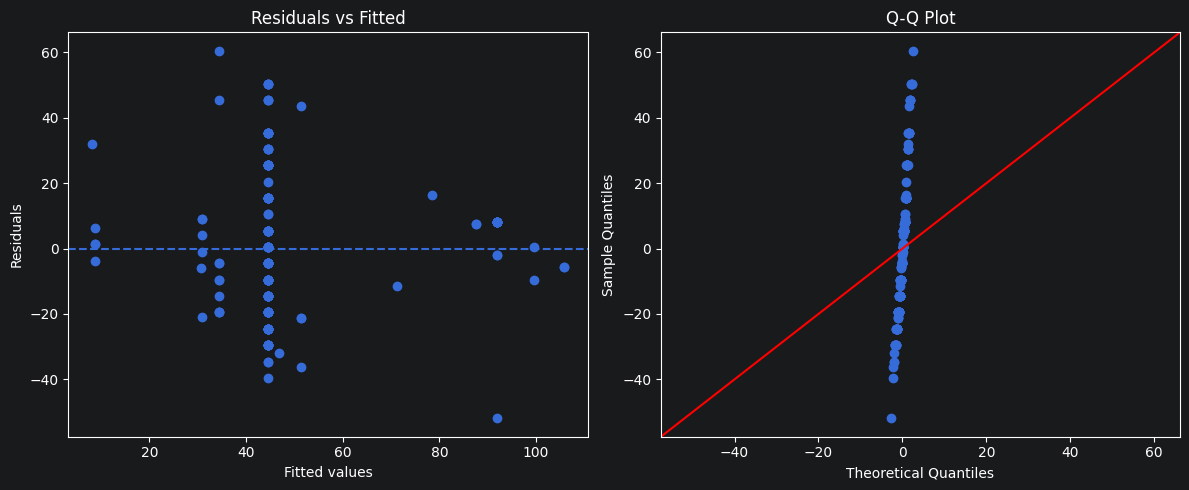

In [30]:
# Basic diagnostic plots for residual 3. analysis

fitted_vals = model_rsm1.fittedvalues
residuals = model_rsm1.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Residuals vs fitted
axes[0].scatter(fitted_vals, residuals)
axes[0].axhline(0, linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

# Q-Q plot
sm.qqplot(residuals, line="45", ax=axes[1])
axes[1].set_title("Q-Q Plot")

plt.tight_layout()
plt.show()

- The residuals versus fit plot shows that residuals are generally clustered around zero, but some observations have large residual values, ranging from -50 to +60. This model will introduce significant prediction errors for some experiments. Furthermore, the wide dispersion of residuals, especially around similar fit values, suggests that the model does not fully capture all sources of variation in the response.
- The Q-Q plot shows deviations from the reference line, indicating that residuals are not perfectly normally distributed.
- Therefore, although this model is useful in determining the relationship between the factor and the local response, its predictive accuracy and statistical assumptions are limited, so the optimal predicted value needs to be validated in the laboratory.

The hypothesis regarding the promising region from EDA is statistically plausible, but historical data on this region are insufficient to definitively confirm it or find the optimal point. Therefore, practical confirmation from the laboratory is still necessary.

Promising conditions:
- Flow Rate Ratio: **6–8**
- Dispersed Flow Rate: **24–30 mL/min**
- Impellor Speed: **50–112 rpm**